# SpaceRec

This notebook runs the SpaceRec workflow on an existing BRCA Visium dataset. It starts at **Step 1** because spatial counts, coordinates, scale factors, the H&E image, and the single-cell reference already exist.

The supplied deconvolution proportions are reused after barcode and normalization checks. The RCTD expression reference and every artifact from grid embedding onward are generated in the SpaceRec output directories of `resources/brca`. Downloaded v1 outputs are not read.

| Step | SpaceRec operation | Main output |
| --- | --- | --- |
| 1 | Validate supplied deconvolution and build an RCTD expression reference | 11-cell-type proportions, `mu_ref`, gene list |
| 2 | Dense30 Virchow2 embedding and H&E mask | 3840-dimensional filtered grid embeddings |
| 3.1 | router/type training | Stage 1 checkpoint and grid type probabilities |
| 3.2 | finetune-mu expression training | Stage 2 checkpoint, grid type and expression predictions |
| 4 | View predictions inside an editable full-resolution bbox | Grid-level type and gene-expression plots |

In [1]:
from __future__ import annotations

import json
import os
import re
import subprocess
import sys
from pathlib import Path
from pprint import pprint


def expand_gpu_indices(spec: str) -> list[int]:
    indices: list[int] = []
    for part in spec.split(','):
        bounds = part.strip().split('-', maxsplit=1)
        if len(bounds) == 1:
            indices.append(int(bounds[0]))
        else:
            indices.extend(range(int(bounds[0]), int(bounds[1]) + 1))
    return indices


# A direct VS Code shell on a Slurm node may omit CUDA_VISIBLE_DEVICES. Restrict
# CUDA to the GPUs assigned to the current job before importing PyTorch.
if not os.environ.get('CUDA_VISIBLE_DEVICES') and os.environ.get('SLURM_JOB_ID'):
    job_info = subprocess.run(
        ['scontrol', 'show', 'job', '-dd', os.environ['SLURM_JOB_ID']],
        check=True, capture_output=True, text=True, timeout=30,
    ).stdout
    match = re.search(r'GRES=gpu:[^\s]*\(IDX:([0-9,-]+)\)', job_info)
    if match:
        os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(map(str, expand_gpu_indices(match.group(1))))

import anndata as ad
import h5py
import numpy as np
import pandas as pd
import torch


def find_spacerec_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in (start, *start.parents):
        if (path / 'spacerec' / 'api.py').is_file():
            return path
    raise FileNotFoundError('Could not find the repository root containing spacerec/api.py')


def require_files(*paths: Path) -> None:
    missing = [str(path) for path in paths if not path.is_file() or path.stat().st_size == 0]
    if missing:
        raise FileNotFoundError('Missing required files:\n' + '\n'.join(missing))


ROOT = find_spacerec_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import spacerec.api as spacerec

ad.settings.allow_write_nullable_strings = True
dataset = 'brca'
sample_id = 'BREAST'
resource_root = ROOT / 'resources' / dataset
deconv_dir = resource_root / 'deconv'
rctd_ref_dir = deconv_dir / 'rctd_ref'
embedding_dir = resource_root / 'embedding'
mask_dir = resource_root / 'mask'
type_pred_dir = resource_root / 'model_pred'
train_dir = type_pred_dir / 'train'

visium_dir = resource_root / 'visium'
visium_h5 = visium_dir / 'st_filtered_feature_bc_matrix.h5'
positions_csv = visium_dir / 'tissue_positions.csv'
scalefactors_json = visium_dir / 'scalefactors_json.json'
thumbnail_png = visium_dir / 'spatial' / 'tissue_hires_image.png'
he_image = resource_root / 'he' / 'he.tif'
sc_ref_h5ad = resource_root / 'sc_ref' / 'scRNA_adata_reannotated.h5ad'
deconv_csv = resource_root / 'deconv' / 'deconv.csv'
brca_merge_json = ROOT / 'spacerec' / 'deconv' / 'brca_type_merge_17to11.json'
gene_list = resource_root / 'gene_list' / 'gene.txt'
r_env = Path(os.environ.get('SPACEREC_R_ENV', Path.home() / '.conda' / 'envs' / 'spacerec_r_env'))

require_files(
    visium_h5, positions_csv, scalefactors_json, thumbnail_png, he_image,
    sc_ref_h5ad, deconv_csv, brca_merge_json,
)
if not (r_env / 'bin' / 'Rscript').is_file():
    raise FileNotFoundError(f'RCTD R environment is missing: {r_env}')
os.environ['PATH'] = str(r_env / 'bin') + os.pathsep + os.environ.get('PATH', '')
resource_root.mkdir(parents=True, exist_ok=True)

cuda_summary = {
    'slurm_job_id': os.environ.get('SLURM_JOB_ID'),
    'cuda_visible_devices': os.environ.get('CUDA_VISIBLE_DEVICES'),
    'cuda_available': torch.cuda.is_available(),
    'cuda_device_count': torch.cuda.device_count(),
    'cuda_device_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
}
pprint(cuda_summary)
if os.environ.get('SPACEREC_REQUIRE_CUDA') == '1' and not cuda_summary['cuda_available']:
    raise RuntimeError('SPACEREC_REQUIRE_CUDA=1, but PyTorch cannot access an allocated GPU.')

{'root': ROOT, 'resources_and_outputs': resource_root, 'r_env': r_env}


{'cuda_available': True,
 'cuda_device_count': 2,
 'cuda_device_name': 'Tesla V100-SXM2-32GB',
 'cuda_visible_devices': '0,1',
 'slurm_job_id': '48957873'}


{'root': PosixPath('/path/to/SpaceRec'),
 'resources_and_outputs': PosixPath('/path/to/SpaceRec/resources/brca'),
 'r_env': PosixPath('/path/to/spacerec_r_env')}

## Step 1: deconvolution inputs and expression reference

The supplied RCTD proportions are accepted only after their barcodes match the Visium matrix exactly, all values are finite and nonnegative, and every row sums to one. `spacerec.rctd_ref(...)` is then run on the real Visium counts and single-cell reference to create the ordered gene list and the 11-cell-type expression prior required by the finetune-mu model.

For spot $s$, cell type $k$, and gene $g$, the proportions and reference profiles are normalized as

$$w_{sk}\ge 0,\qquad \sum_k w_{sk}=1,\qquad \mu^{ref}_{kg}=\frac{r_{kg}}{\sum_{g'}r_{kg'}}.$$

In [2]:
with h5py.File(visium_h5, 'r') as handle:
    visium_barcodes = [x.decode() if isinstance(x, bytes) else str(x) for x in handle['matrix/barcodes'][:]]
deconv = pd.read_csv(deconv_csv, index_col=0)
if set(deconv.index.astype(str)) != set(visium_barcodes):
    raise ValueError('The supplied deconvolution barcodes do not match the Visium H5 barcodes.')
values = deconv.to_numpy(dtype=np.float64)
if not np.isfinite(values).all() or np.any(values < 0):
    raise ValueError('Deconvolution proportions must be finite and nonnegative.')
if not np.allclose(values.sum(axis=1), 1.0, atol=1e-6):
    raise ValueError('Deconvolution rows must sum to one.')
deconv_summary = {
    'source': str(deconv_csv),
    'reused_supplied_result': True,
    'n_spots': int(deconv.shape[0]),
    'n_cell_types': int(deconv.shape[1]),
    'cell_types': deconv.columns.tolist(),
}
pprint(deconv_summary)

rctd_ref_summary = spacerec.rctd_ref(
    dataset=dataset,
    sc_ref_h5ad=sc_ref_h5ad,
    synthetic_h5=visium_h5,  # API name retained for compatibility; this is the real Visium H5.
    positions_csv=positions_csv,
    output_dir=rctd_ref_dir,
    gene_list_txt=gene_list,
    r_env_prefix=None,  # Rscript is resolved directly from r_env/bin added to PATH above.
    merge_json=brca_merge_json,
    force=True,
)
mu_ref = rctd_ref_dir / 'rctd_reference_merged11.npy'
require_files(gene_list, mu_ref, rctd_ref_dir / 'rctd_reference_merged11.csv')
pprint(rctd_ref_summary)
{'deconvolution': deconv_summary, 'mu_ref_shape': np.load(mu_ref).shape, 'gene_list': gene_list}


{'cell_types': ['B Cells',
                'T Cells',
                'DCIS',
                'Endothelial',
                'Invasive Tumor',
                'DCs',
                'Macrophages',
                'Mast Cells',
                'Myoepi',
                'Perivascular-Like',
                'Stromal'],
 'n_cell_types': 11,
 'n_spots': 4992,
 'reused_supplied_result': True,
 'source': '/path/to/SpaceRec/resources/brca/deconv/deconv.csv'}
{'cell_type_order': ['B Cells',
                     'T Cells',
                     'DCIS',
                     'Endothelial',
                     'Invasive Tumor',
                     'DCs',
                     'Macrophages',
                     'Mast Cells',
                     'Myoepi',
                     'Perivascular-Like',
                     'Stromal'],
 'cell_type_order_txt': '/path/to/SpaceRec/resources/brca/deconv/rctd_ref/cell_type_order.txt',
 'csv': '/path/to/SpaceRec/resources/brca/deconv/rctd_ref/rctd_reference_mer

{'deconvolution': {'source': '/path/to/SpaceRec/resources/brca/deconv/deconv.csv',
  'reused_supplied_result': True,
  'n_spots': 4992,
  'n_cell_types': 11,
  'cell_types': ['B Cells',
   'T Cells',
   'DCIS',
   'Endothelial',
   'Invasive Tumor',
   'DCs',
   'Macrophages',
   'Mast Cells',
   'Myoepi',
   'Perivascular-Like',
   'Stromal']},
 'mu_ref_shape': (11, 17649),
 'gene_list': PosixPath('/path/to/SpaceRec/resources/brca/gene_list/gene.txt')}

## Step 2: grid embedding and H&E mask

The dense30 configuration uses a 480-pixel patch, 120-pixel stride, and Virchow2 token plus local tile features. Neighbor features remain disabled, giving the 3840-dimensional input expected when `skip_input_projector=True`. The H&E-only mask removes background grids before training.

With a $16\times16$ token layout, each output grid is 30 full-resolution pixels wide:

$$q=\frac{P}{16}=\frac{480}{16}=30\ {\rm px},\qquad S=\frac{P}{4}=120\ {\rm px}.$$

The feature and retained training set are

$$z_i=[t_i;\ell_i]\in\mathbb{R}^{1280+2560}=\mathbb{R}^{3840},\qquad \mathcal G_{\rm train}=\{i:m_i=1\}.$$

In [3]:
grid_embedding_h5 = embedding_dir / 'dense30_virchow2_3840_visium_he_bbox_allgrid.h5'
ge_summary = spacerec.ge(
    dataset=dataset,
    sample_id=sample_id,
    he_image=he_image,
    positions_csv=positions_csv,
    scalefactors_json=scalefactors_json,
    thumbnail_png=thumbnail_png,
    output_dir=embedding_dir,
    output_h5=grid_embedding_h5,
    patch_size=480,
    stride=120,
    concat_local=True,
    concat_nbr=False,
    model='virchow2',
    batch_size=4,
    num_workers=4,
    force=True,
    auto_select_gpu=True,
    enable_progress_bar=True,
    progress_refresh_rate=5.0,
    stage_log_stdout=False,
)
require_files(grid_embedding_h5)
with h5py.File(grid_embedding_h5, 'r') as handle:
    feature_keys = [key for key, value in handle.items() if isinstance(value, h5py.Dataset) and value.ndim == 2 and value.shape[1] == 3840]
    if len(feature_keys) != 1:
        raise ValueError(f'Expected one 3840-dimensional feature matrix, found {feature_keys}')
    embedding_shape = tuple(handle[feature_keys[0]].shape)
pprint(ge_summary)
{'feature_key': feature_keys[0], 'shape': embedding_shape, 'output': grid_embedding_h5}


Grid embeddings: 100%|██████████| 2524/2524 [02:28<00:00, 17.04batch/s]


{'api_summary': {'dataset': 'brca',
                 'metadata_only': False,
                 'output_h5': '/path/to/SpaceRec/resources/brca/embedding/dense30_virchow2_3840_visium_he_bbox_allgrid.h5',
                 'sample_id': 'BREAST',
                 'stage': 'dense18_virchow2'},
 'complete': True,
 'concat_local': True,
 'concat_nbr': False,
 'dataset': 'brca',
 'device': 'cuda:0',
 'elapsed_seconds': 246.91887760162354,
 'feature_dim': 3840,
 'feature_key': 'virchow2_token_tile_concat3840',
 'filter_grid_tissue_boundary': False,
 'filter_patch_tissue_boundary': False,
 'gpu_selection': {'cuda_device_arg': 0,
                   'enabled': True,
                   'memory_free_mb': 32491,
                   'memory_used_mb': 4,
                   'method': 'torch.cuda.set_device',
                   'physical_index': 4,
                   'previous_cuda_visible_devices': '4,5',
                   'selected': True,
                   'utilization_gpu_percent': 0,
                

{'feature_key': 'virchow2_token_tile_concat3840',
 'shape': (159490, 3840),
 'output': PosixPath('/path/to/SpaceRec/resources/brca/embedding/dense30_virchow2_3840_visium_he_bbox_allgrid.h5')}

In [ ]:
mask_h5 = mask_dir / 'he_mask_grid.h5'
training_grid_embedding_h5 = embedding_dir / 'grid_embedding_train_filtered.h5'
mask_summary = spacerec.mask(
    dataset=dataset,
    grid_embedding_h5=grid_embedding_h5,
    output_dir=mask_dir,
    output_h5=mask_h5,
    training_h5=training_grid_embedding_h5,
    he_image=he_image,
    mode='he',
    force=True,
)
require_files(mask_h5, training_grid_embedding_h5)
pprint(mask_summary)
training_grid_embedding_h5


## Step 3.1: Stage 1 router and cell-type model

Stage 1 trains the router/type head against the validated 11-type Visium proportions. It uses the direct 3840-dimensional input and a two-layer type head. This step writes only the Stage 1 checkpoint and grid-level type probabilities.

Each grid $i$ receives a type distribution; grid probabilities are averaged within Visium spot $s$:

$$p_{ik}=\operatorname{softmax}(f_{\psi}(z_i))_k,\qquad \hat w_{sk}=\frac{1}{|\mathcal G_s|}\sum_{i\in\mathcal G_s}p_{ik}.$$

The Stage 1 objective matches RCTD proportions and encourages confident grid predictions:

$$\mathcal L_1=\operatorname{KL}(w_s\,\|\,\hat w_s)+\lambda_{\rm conf}\left[-\frac{1}{|\mathcal G_s|}\sum_{i\in\mathcal G_s}\log\max_k p_{ik}\right].$$

In [ ]:
stage1_summary = spacerec.stage1(
    dataset=dataset,
    st_h5ad=visium_h5,
    deconv_csv=deconv_csv,
    grid_embedding_h5=training_grid_embedding_h5,
    gene_list=gene_list,
    mu_ref=mu_ref,
    run_dir=train_dir,
    projection_dim=2048,
    skip_input_projector=True,
    type_head_hidden_layers=2,
    factorized_head_hidden_layers=3,
    scale_head_hidden_dim=512,
    delta_head_hidden_dim=2048,
    batch_size=4,
    lr=5e-5,
    alpha=0.1,
    delta_alpha=0.5,
    limit_spots=None,
    auto_select_gpu=True,
    enable_progress_bar=True,
    progress_refresh_rate=5,
    stage_log_stdout=False,
    stage1_epochs=70,
    agg=False,
    type_pred_dir=type_pred_dir,
)
stage1_checkpoint = train_dir / 'model' / 'stage1_router' / 'checkpoints' / 'best.ckpt'
require_files(stage1_checkpoint, type_pred_dir / 'stage1_grid_type.csv')
pprint(stage1_summary)

## Step 3.2: Stage 2 finetune-mu expression model

Stage 2 initializes from the best Stage 1 checkpoint and learns cell-type-specific scale and expression adjustments around the RCTD reference. It writes only the Stage 2 checkpoint and grid-level type and expression predictions. This cell is restart-safe: after reopening the notebook, run Setup and then this cell; it resolves and validates every Stage 2 input from disk.

The frozen Stage 1 probabilities mix locally adjusted RCTD profiles:

$$\tilde\mu_{ikg}=\operatorname{softmax}_g\!\left(\log\mu^{ref}_{kg}+\delta_{ikg}\right),$$

$$\hat y_{ig}=s_i\sum_k\operatorname{stopgrad}(p_{ik})\tilde\mu_{ikg},\qquad \hat y_{sg}=\sum_{i\in\mathcal G_s}\hat y_{ig}.$$

Expression training uses the spot-level log-count Huber loss:

$$\mathcal L_2=\sum_{s,g}\operatorname{Huber}\!\left(\log(1+\hat y_{sg}),\log(1+y_{sg})\right).$$

In [ ]:
mu_ref = rctd_ref_dir / 'rctd_reference_merged11.npy'
training_grid_embedding_h5 = embedding_dir / 'grid_embedding_train_filtered.h5'
stage1_checkpoint = train_dir / 'model' / 'stage1_router' / 'checkpoints' / 'best.ckpt'
grid_pred_expression_h5 = train_dir / 'grid_pred_expression.h5'
require_files(gene_list, mu_ref, training_grid_embedding_h5, deconv_csv, visium_h5, stage1_checkpoint)

stage2_summary = spacerec.stage2(
    dataset=dataset,
    st_h5ad=visium_h5,
    deconv_csv=deconv_csv,
    grid_embedding_h5=training_grid_embedding_h5,
    gene_txt=gene_list,
    mu_ref=mu_ref,
    run_dir=train_dir,
    stage1_checkpoint=stage1_checkpoint,
    projection_dim=2048,
    skip_input_projector=True,
    type_head_hidden_layers=2,
    factorized_head_hidden_layers=3,
    scale_head_hidden_dim=512,
    delta_head_hidden_dim=2048,
    batch_size=4,
    lr=5e-5,
    alpha=0.1,
    delta_alpha=0.5,
    limit_spots=None,
    auto_select_gpu=True,
    enable_progress_bar=True,
    progress_refresh_rate=5,
    stage_log_stdout=False,
    stage2_epochs=70,
    agg=False,
    grid_pred_expression_h5=grid_pred_expression_h5,
)
grid_predictions_h5 = train_dir / 'grid_predictions.h5'
grid_type_csv = train_dir / 'grid_type.csv'
grid_expr_h5ad = train_dir / 'grid_expr.h5ad'
stage2_checkpoint = train_dir / 'model' / 'stage2_expression' / 'checkpoints' / 'best.ckpt'
require_files(stage2_checkpoint, grid_predictions_h5, grid_type_csv, grid_expr_h5ad, grid_pred_expression_h5)
pprint(stage2_summary)

## Step 4: inspect grid-level predictions in a bbox

Set one full-resolution H&E bounding box $(x_0,y_0,x_1,y_1)$ and one gene below. The type panel displays

$$\hat k_i=\arg\max_k p_{ik}$$

for every intersecting 30 px grid using the fixed BRCA colors from `resources/brca/model_pred/train/metrics/windows`. The expression panel uses the same black-background `magma` scale:

$$z_{ig}=\operatorname{clip}\!\left(\frac{\hat y_{ig}-\mu_g}{\sigma_g},-2,2\right),$$

where $\mu_g$ and $\sigma_g$ are calculated independently within the selected bbox for this plot. Every expression plot keeps color limits `[-2, 2]` while using its own mean and standard deviation. Both PNGs are displayed inline and written under the current run's `metrics/windows/window_x0_y0_x1_y1` directory.

{'bbox_xyxy': [10052, 6800, 11593, 8363],
 'expression': {'dataset': 'brca',
                'grid_expr_png': '/path/to/SpaceRec/resources/brca/model_pred/train/metrics/windows/window_10052_6800_11593_8363/KRT5_grid_expr.png',
                'output_dir': '/path/to/SpaceRec/resources/brca/model_pred/train/metrics/windows/window_10052_6800_11593_8363',
                'output_png': '/path/to/SpaceRec/resources/brca/model_pred/train/metrics/windows/window_10052_6800_11593_8363/KRT5_grid_expr.png'},
 'gene': 'KRT5',
 'side_by_side_png': '/path/to/SpaceRec/resources/brca/model_pred/train/metrics/windows/window_10052_6800_11593_8363/KRT5_grid_type_and_expr.png',
 'type': {'dataset': 'brca',
          'grid_type_png': '/path/to/SpaceRec/resources/brca/model_pred/train/metrics/windows/window_10052_6800_11593_8363/predicted_type.png',
          'output_dir': '/path/to/SpaceRec/resources/brca/model_pred/train/metrics/windows/window_10052_6800_11593_8363',
          'output_png': '/path/to/Spac

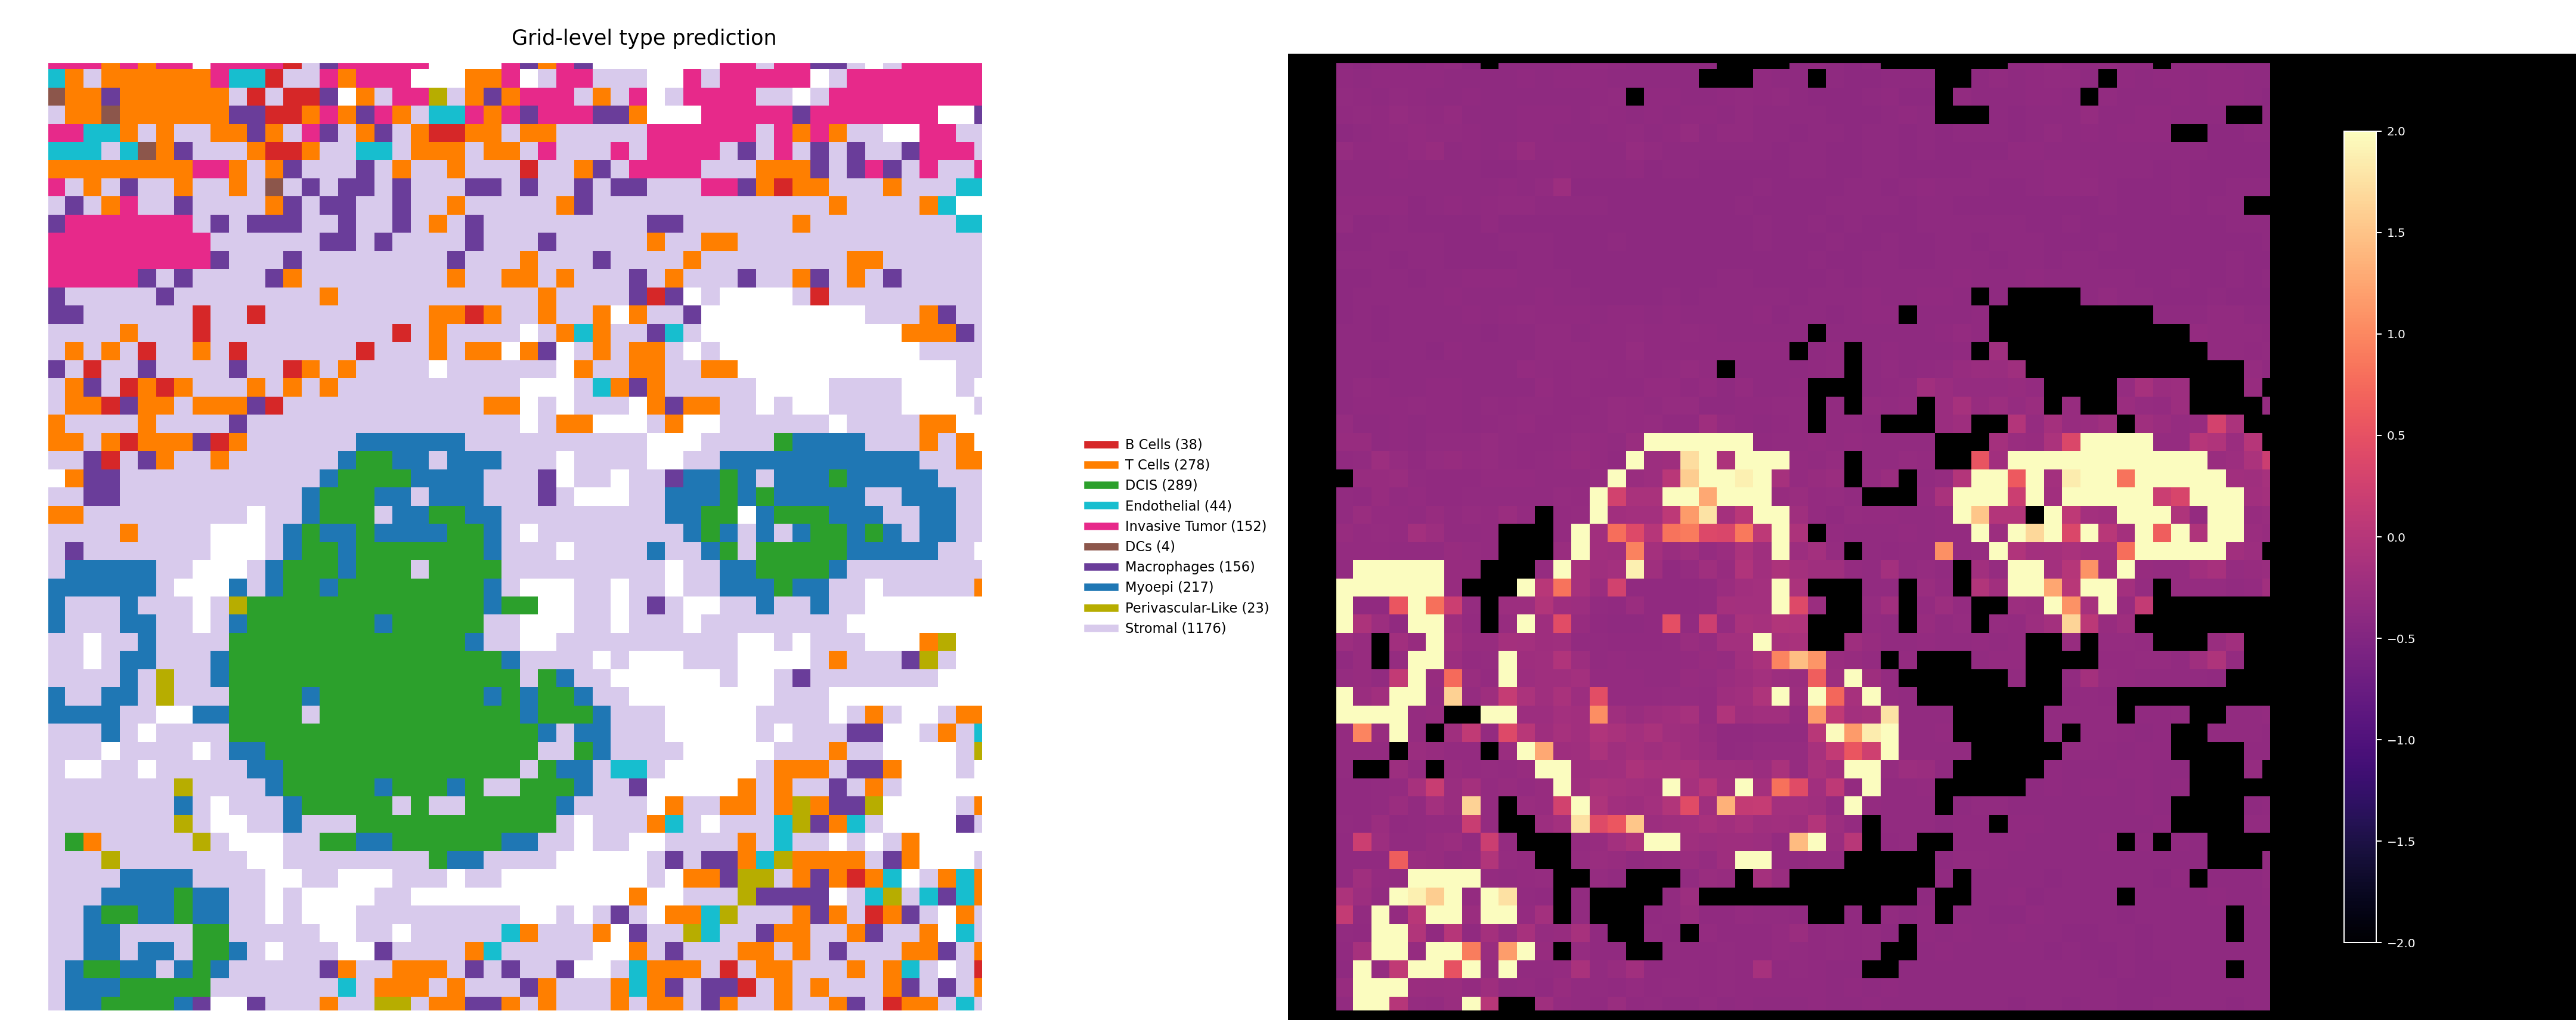

In [2]:
import importlib

import matplotlib.pyplot as plt
from IPython.display import Image, display
import spacerec.evaluation as evaluation
import spacerec.evaluation.plot as evaluation_plot

# Reload local plotting code so this cell also works in a kernel started before code edits.
importlib.reload(evaluation_plot)
importlib.reload(evaluation)

bbox_xyxy = (10052, 6800, 11593, 8363)  # editable full-resolution H&E bbox: x0, y0, x1, y1
expression_gene = 'KRT5'

grid_type_csv = train_dir / 'grid_type.csv'
grid_expr_h5ad = train_dir / 'grid_expr.h5ad'
require_files(grid_type_csv, grid_expr_h5ad)

window_name = 'window_' + '_'.join(str(int(value)) for value in bbox_xyxy)
grid_window_dir = train_dir / 'metrics' / 'windows' / window_name
grid_type_summary = spacerec.plottype(
    dataset=dataset,
    grid_type_csv=grid_type_csv,
    window=bbox_xyxy,
    output_dir=grid_window_dir,
    output_name='predicted_type.png',
)
grid_expr_summary = spacerec.plotexpr(
    dataset=dataset,
    grid_expr_h5ad=grid_expr_h5ad,
    window=bbox_xyxy,
    output_dir=grid_window_dir,
    gene=expression_gene,
    output_name=f'{expression_gene}_grid_expr.png',
)
grid_window_individual_outputs = [Path(grid_type_summary['grid_type_png']), Path(grid_expr_summary['grid_expr_png'])]
require_files(*grid_window_individual_outputs)

# Each source PNG is 2160 x 1620 (4:3). The axes below are also exactly
# 2160 x 1620 pixels, so neither panel is stretched or squeezed.
fig, axes = plt.subplots(1, 2, figsize=(24, 9.5), dpi=180)
fig.subplots_adjust(left=0, right=1, bottom=0, top=18 / 19, wspace=0)
for ax, image_path, title in zip(
    axes,
    grid_window_individual_outputs,
    ['Grid-level type prediction', None],
    strict=True,
):
    ax.imshow(plt.imread(image_path), interpolation='nearest')
    if title is not None:
        ax.set_title(title, fontsize=14)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')
grid_window_panel_png = grid_window_dir / f'{expression_gene}_grid_type_and_expr.png'
fig.savefig(grid_window_panel_png, dpi=180, facecolor='white')
plt.close(fig)
grid_window_outputs = [*grid_window_individual_outputs, grid_window_panel_png]
require_files(*grid_window_outputs)
grid_window_summary = {
    'bbox_xyxy': list(bbox_xyxy),
    'gene': expression_gene,
    'type': grid_type_summary,
    'expression': grid_expr_summary,
    'side_by_side_png': str(grid_window_panel_png),
}
grid_window_summary_json = grid_window_dir / 'grid_window_summary.json'
grid_window_summary_json.write_text(json.dumps(grid_window_summary, indent=2), encoding='utf-8')
pprint(grid_window_summary)
display(Image(filename=str(grid_window_panel_png), width=1600))